<a href="https://colab.research.google.com/github/TanyaGupta37/ML-Lab/blob/main/Lab10_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load datasets (semicolon-separated)
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# Add wine type label
red['type'] = 0    # 0 = red
white['type'] = 1  # 1 = white

In [5]:
# Combine
df = pd.concat([red, white], ignore_index=True)
print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


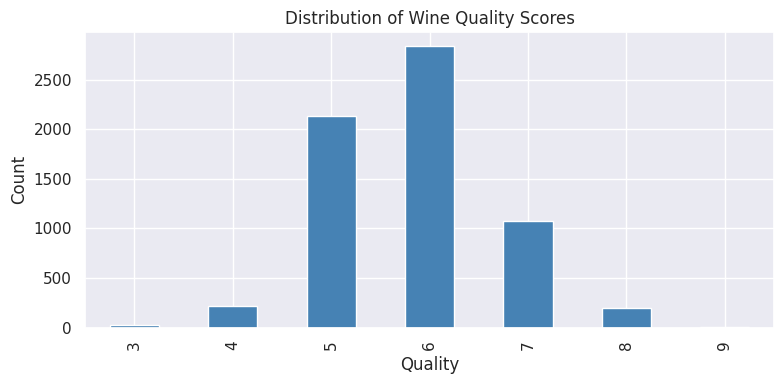

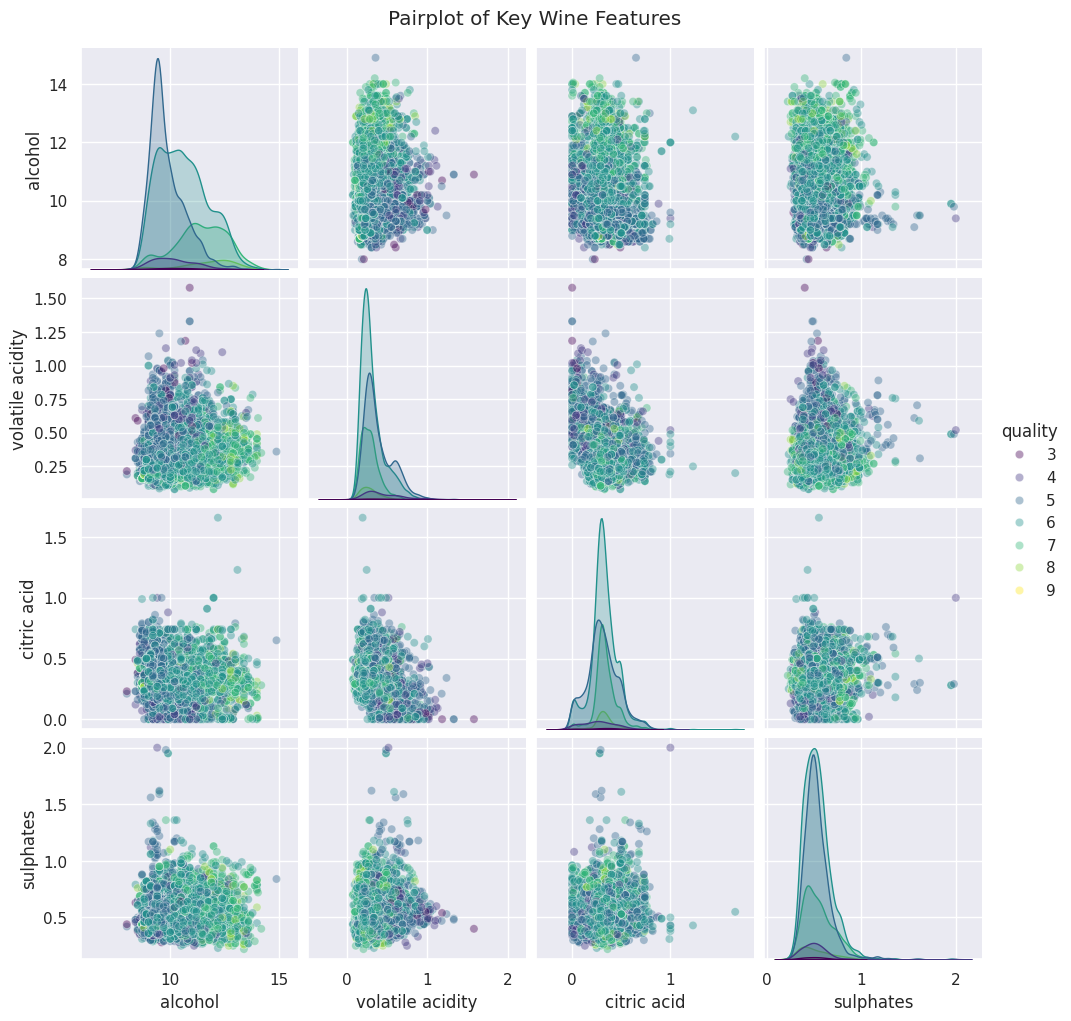

In [6]:
# Distribution of quality scores
plt.figure(figsize=(8, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Pairplot of selected features
sns.pairplot(df[['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'quality']],
             hue='quality', palette='viridis', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Key Wine Features', y=1.02)
plt.show()

In [7]:
# Drop target/label columns for clustering
features = df.drop(columns=['quality', 'type'])

scaler = StandardScaler()
X = scaler.fit_transform(features)

print("Feature matrix shape:", X.shape)
print("Features used:", list(features.columns))

Feature matrix shape: (6497, 11)
Features used: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

print("Cluster counts:", np.bincount(y_kmeans))

Cluster counts: [3009 1896 1592]


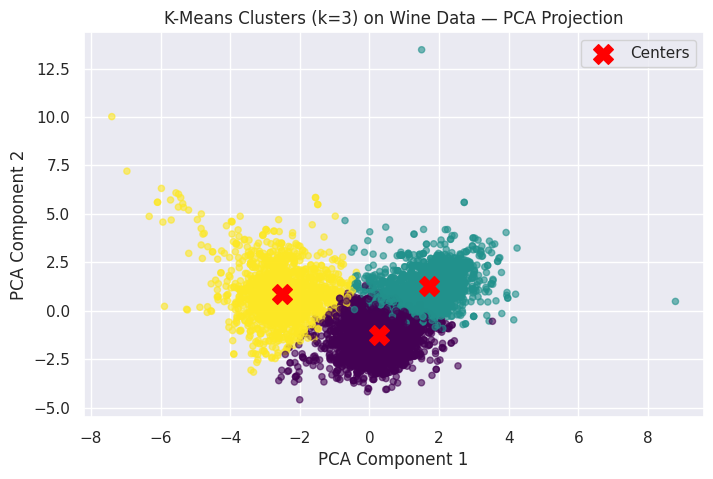

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, s=20, cmap='viridis', alpha=0.6)

# Plot cluster centers projected to PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X', label='Centers')
plt.title('K-Means Clusters (k=3) on Wine Data — PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

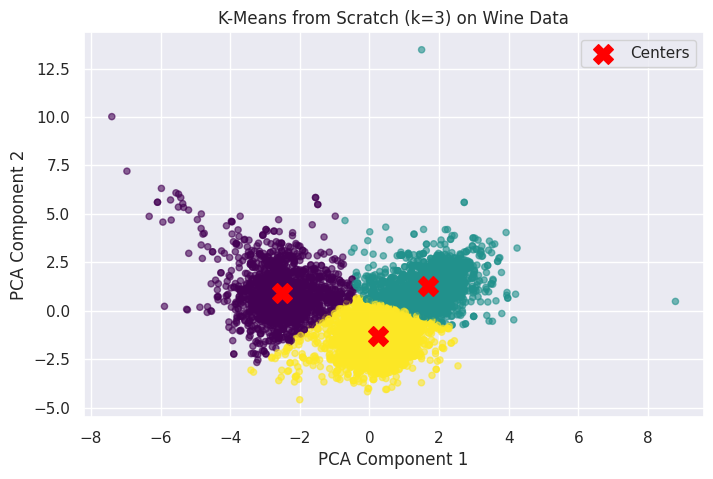

In [10]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        labels = pairwise_distances_argmin(X, centers)
        new_centers = np.array([X[labels == i].mean(0) for i in range(n_clusters)])
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X_pca, 3)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centers')
plt.title('K-Means from Scratch (k=3) on Wine Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

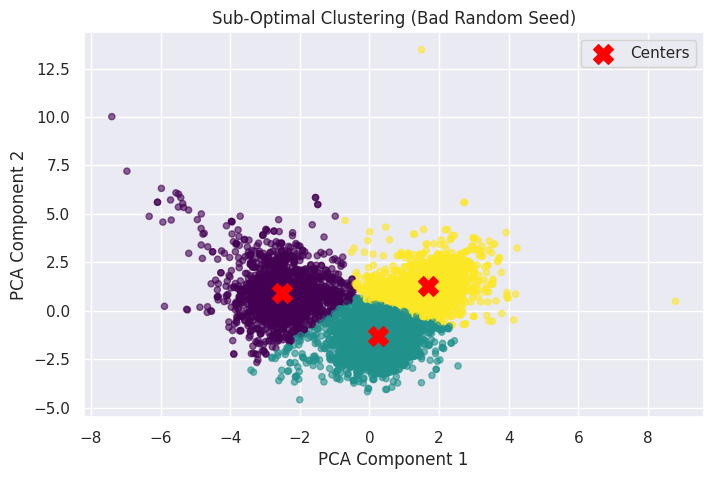

In [11]:
centers_bad, labels_bad = find_clusters(X_pca, 3, rseed=0)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_bad, s=20, cmap='viridis', alpha=0.6)
plt.scatter(centers_bad[:, 0], centers_bad[:, 1], c='red', s=200, marker='X', label='Centers')
plt.title('Sub-Optimal Clustering (Bad Random Seed)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

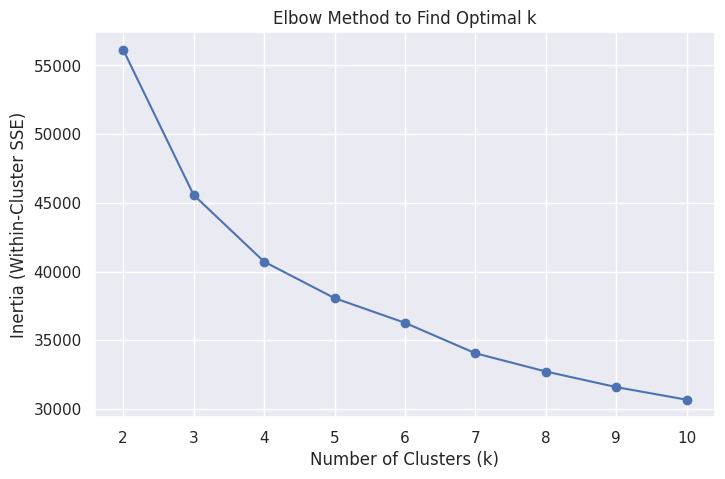

In [12]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method to Find Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

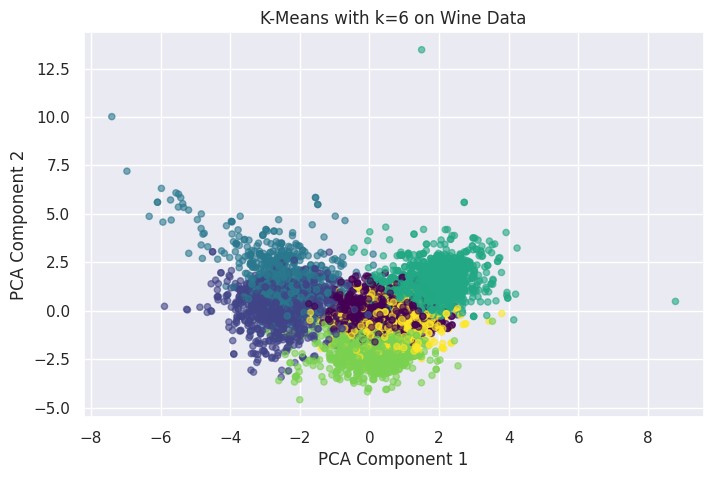

In [13]:
labels6 = KMeans(n_clusters=6, random_state=0, n_init=10).fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels6, s=20, cmap='viridis', alpha=0.6)
plt.title('K-Means with k=6 on Wine Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

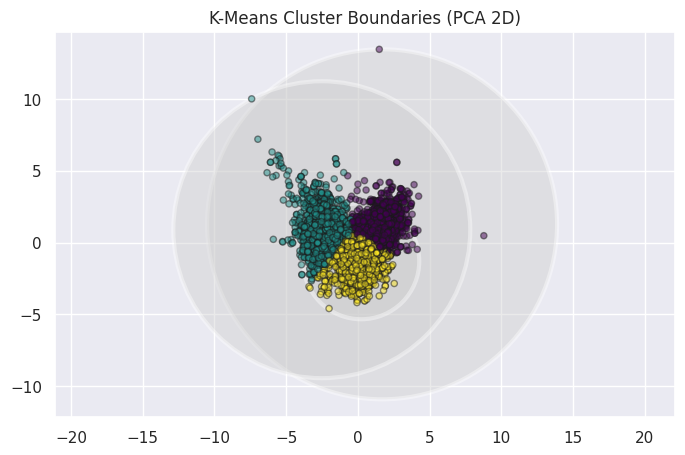

In [14]:
from scipy.spatial.distance import cdist

def plot_kmeans_circles(kmeans, X, ax=None):
    labels = kmeans.fit_predict(X)
    ax = ax or plt.gca()
    ax.axis('equal')
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='viridis', edgecolor='k', alpha=0.5, zorder=2)
    centers = kmeans.cluster_centers_
    radii = [cdist(X[labels == i], [center]).max() for i, center in enumerate(centers)]
    for c, r in zip(centers, radii):
        ax.add_patch(plt.Circle(c, r, fc='#CCCCCC', lw=3, alpha=0.4, zorder=1))

kmeans3 = KMeans(n_clusters=3, random_state=0, n_init=10)
fig, ax = plt.subplots(figsize=(8, 5))
plot_kmeans_circles(kmeans3, X_pca, ax=ax)
ax.set_title('K-Means Cluster Boundaries (PCA 2D)')
plt.show()

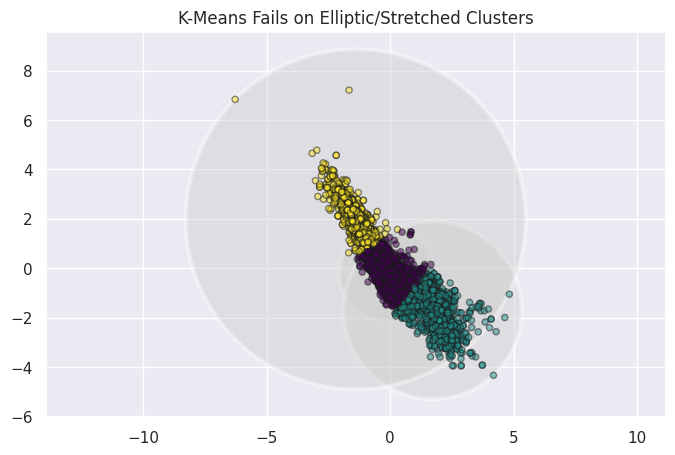

In [15]:
rng = np.random.RandomState(13)
X_stretched = np.dot(X_pca, rng.randn(2, 2))

kmeans_s = KMeans(n_clusters=3, random_state=0, n_init=10)
fig, ax = plt.subplots(figsize=(8, 5))
plot_kmeans_circles(kmeans_s, X_stretched, ax=ax)
ax.set_title('K-Means Fails on Elliptic/Stretched Clusters')
plt.show()

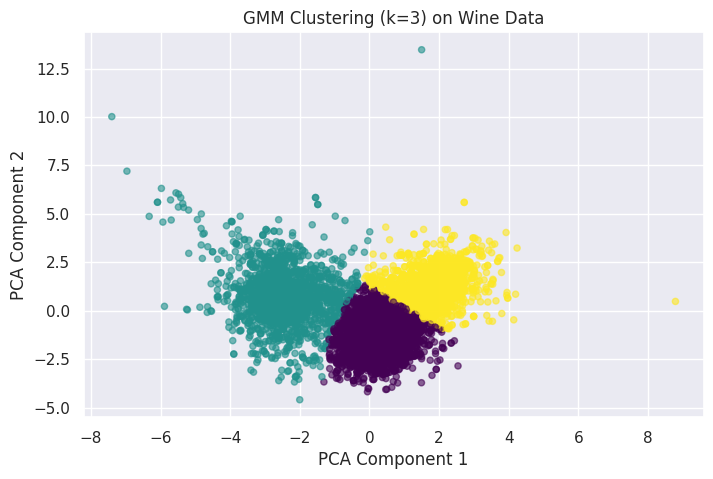

Sample probability assignments (first 5 rows):
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [16]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(X_pca)
labels_gmm = gmm.predict(X_pca)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, s=20, cmap='viridis', alpha=0.6)
plt.title('GMM Clustering (k=3) on Wine Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# Probabilistic assignments
probs = gmm.predict_proba(X_pca)
print("Sample probability assignments (first 5 rows):")
print(probs[:5].round(3))

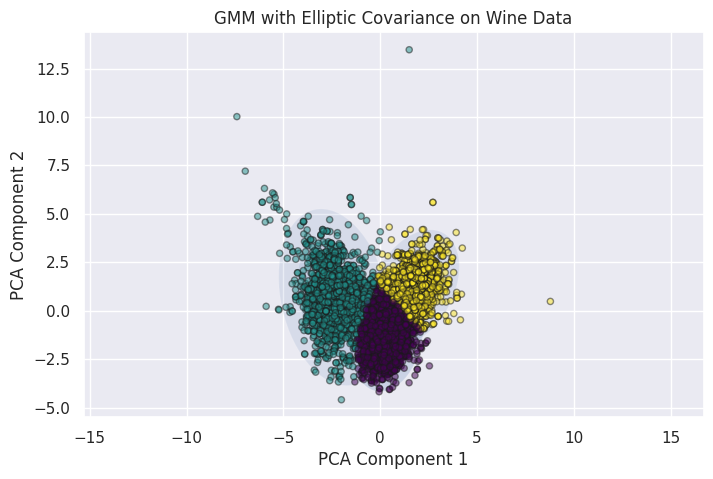

In [17]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height, angle=angle, **kwargs))

def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='viridis', zorder=2, edgecolor='k', alpha=0.5)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=20, zorder=2, edgecolor='k', alpha=0.5)
    ax.axis('equal')
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, ax=ax, alpha=w * w_factor)

gmm_full = GaussianMixture(n_components=3, covariance_type='full', random_state=0)
plt.figure(figsize=(8, 5))
plot_gmm(gmm_full, X_pca)
plt.title('GMM with Elliptic Covariance on Wine Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()